In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

In [49]:
TEMP = 23 #celcius
HUMIDITY = 61 #%
PRESSURE = 992e2 / 133.322387415 #mmhg
DENSITY = (0.46455 * PRESSURE - 61 * (0.00252 * TEMP - 0.020582)) / (TEMP + 273.15) #kg/m3
print(DENSITY)

H_ATM = 136 #mm
H_PITOT = 14.65 #mm
CORDLENGTH = 0.15 #m
Q = H_PITOT * 9.81 #Pa
print(Q)

plot_configs = [
    ('0', 0, 'indianred'),
    ('6', 6, 'steelblue'),
    ('m4', -4, 'lightseagreen')
]

1.1594581064279144
143.71650000000002


In [50]:
col = ['tap', 'x', 'surface', 'h0', 'h6', 'hm4']
df = pd.read_csv('naca0012_ex1.csv', sep=',', skiprows=1, names=col)

print(df)

    tap      x surface   h0   h6  hm4
0     0    0.0      LE  121  125  123
1     1    7.5   Upper  139  157  132
2     2    7.5   Lower  140  127  150
3     3   15.0   Upper  139  156  135
4     4   15.0   Lower  140  132  146
5     5   22.5   Upper  139  145  136
6     6   22.5   Lower  140  133  144
7     7   30.0   Upper  139  145  136
8     8   30.0   Lower  140  133  143
9     9   45.0   Upper  138  143  137
10   10   45.0   Lower  139  133  142
11   11   60.0   Upper  139  141  137
12   12   60.0   Lower  139  134  142
13   13   75.0   Upper  139  139  138
14   14   75.0   Lower  139  135  141
15   15   90.0   Upper  139  138  139
16   16   90.0   Lower  139  135  140
17   17  105.0   Upper  139  137  138
18   18  105.0   Lower  139  135  139
19   19  120.0   Upper  139  137  137
20   20  120.0   Lower  139  135  139


<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\c'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\c'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\c'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1793/2954102946.py:20: SyntaxWarning: invalid escape sequence '\m'
  label=f'$\mathrm{{AOA}}={aoa_val}^\circ$ (Upper)', marker='o', color=color, markersize=5, lw=1)
/tmp/ipykernel_1793/2954102946.py:20: SyntaxWarning: invalid escape sequence '\c'
  label=f'$\mathrm{{AOA}}={aoa_val}^\circ$ (Upper)', marker='o', color=color, markersize=5, lw=1)
/tmp/ipykernel_1793/2954102946.py:23: SyntaxWarning: invalid escape sequence '\m'
  label=f'$\mathrm{{AOA}}={aoa_val}^\circ$ (Lower)', marker='s', color=color, markersize=5, linestyle='--', lw=1)
/tmp/ipykernel_1793/2954102946.py:23

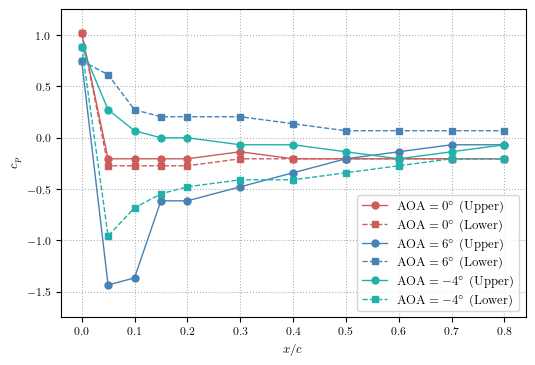

In [55]:
df['xc'] = df['x'] / (CORDLENGTH * 1000)

for suffix, aoa_val, color in plot_configs:
    df[f'dh{suffix}'] = H_ATM - df[f'h{suffix}']
    df[f'dp{suffix}'] = 1000 * 9.81 * df[f'dh{suffix}'] * 0.001
    df[f'p{suffix}'] = df[f'dp{suffix}'] + 992e2
    df[f'cp{suffix}'] = df[f'dp{suffix}'] / Q

df[['tap', 'dh0', 'dh6', 'dhm4']].to_csv('manometer.csv', index=False)
df[['tap', 'p0', 'p6', 'pm4']].to_csv('pressure.csv', index=False, float_format='%.2f')
df[['tap', 'xc', 'surface', 'cp0', 'cp6', 'cpm4']].to_csv('cp.csv', index=False, float_format='%.2f')

df_upper = df[df['surface'].isin(['LE', 'Upper'])]
df_lower = df[df['surface'].isin(['LE', 'Lower'])]

fig, ax = plt.subplots(figsize=(6,4))

for suffix, aoa_val, color in plot_configs:
    ax.plot(df_upper['xc'], df_upper[f'cp{suffix}'],
            label=f'$\mathrm{{AOA}}={aoa_val}^\circ$ (Upper)', marker='o', color=color, markersize=5, lw=1)
    
    ax.plot(df_lower['xc'], df_lower[f'cp{suffix}'], 
            label=f'$\mathrm{{AOA}}={aoa_val}^\circ$ (Lower)', marker='s', color=color, markersize=5, linestyle='--', lw=1)
    
ax.set_xlabel('$x/c$')
ax.set_ylabel('$c_p$')
ax.set_ylim(-1.75,1.25)
ax.legend(loc='lower right')
ax.grid(True, linestyle=':')

fig.savefig('cp.pdf', format='pdf', bbox_inches='tight')
plt.show()

[-0.03554686 -0.0468277  -0.0534516  -0.05737543 -0.06001727 -0.05803011
 -0.05294025 -0.04563369 -0.03663907 -0.02623118]


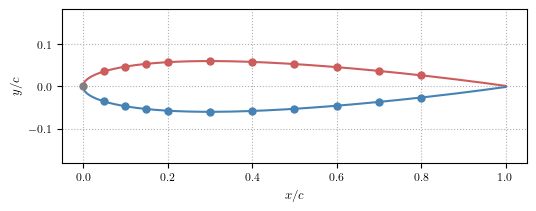

In [52]:
def naca0012_y(x):
    return 5 * 0.12 * (0.2969 * np.sqrt(x) - 0.1260 * x - 0.3516 * x**2 + 0.2843 * x**3 - 0.1015 * x**4)

x = np.linspace(0, 1, 1000)

y_upper = naca0012_y(x)
y_lower = -naca0012_y(x)

fig, ax = plt.subplots(figsize=(6,2))
ax.plot(x, y_upper, color='indianred', label='Upper Surface')
ax.plot(x, y_lower, color='steelblue', label='Lower Surface')

tap_x_raw = np.array([7.5, 15, 22.5, 30, 45, 60, 75, 90, 105, 120])
tap_x = tap_x_raw / 150.0

tap_y_upper = naca0012_y(tap_x)
tap_y_lower = -naca0012_y(tap_x)

print(tap_y_lower)

ax.plot(tap_x, tap_y_upper, 'o', color='indianred',  markersize=5)
ax.plot(tap_x, tap_y_lower, 'o', color='steelblue',  markersize=5)
ax.plot(0, 0, 'o', color='gray',  markersize=5)

ax.axis('equal')
ax.set_xlabel('$x/c$')
ax.set_ylabel('$y/c$')
ax.grid(True, linestyle=':')

fig.savefig('naca0012.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [54]:
df['yc'] = naca0012_y(df['xc'])
df.loc[df['surface'] == 'Lower', 'yc'] = -df.loc[df['surface'] == 'Lower', 'yc']
df.loc[df['surface'] == 'LE', 'yc'] = 0.0

# Closed-loop
df_lower = df[df['surface'] == 'Lower'].sort_values(by='xc', ascending=False)
df_le = df[df['surface'] == 'LE']
df_upper = df[df['surface'] == 'Upper'].sort_values(by='xc', ascending=True)

df_seq = pd.concat([df_lower, df_le, df_upper]).reset_index(drop=True)

# Intergration
aoas = {'cp0': 0.0, 'cp6': 6.0, 'cpm4': -4.0}
results = {}

for col, aoa_deg in aoas.items():
    aoa_rad = np.radians(aoa_deg)
    
    c_a = 0.0 
    c_n = 0.0 
    
    for i in range(len(df_seq) - 1):
        cp_avg = (df_seq.loc[i, col] + df_seq.loc[i+1, col]) / 2.0
        dxc = df_seq.loc[i+1, 'xc'] - df_seq.loc[i, 'xc']
        dyc = df_seq.loc[i+1, 'yc'] - df_seq.loc[i, 'yc']
        
        c_a += cp_avg * dyc
        c_n += -cp_avg * dxc
        
    c_l = c_n * np.cos(aoa_rad) - c_a * np.sin(aoa_rad)
    c_d = c_n * np.sin(aoa_rad) + c_a * np.cos(aoa_rad)
    
    F_x = c_a * Q * CORDLENGTH
    F_y = c_n * Q * CORDLENGTH
    L_prime = c_l * Q * CORDLENGTH
    D_prime = c_d * Q * CORDLENGTH
    
    results[aoa_deg] = {'F_x': F_x, 'F_y': F_y, "L'": L_prime, "D'": D_prime, 'c_l': c_l, 'c_d': c_d}

for aoa, res in results.items():
    print(f"AOA = {aoa}deg:")
    for key, val in res.items():
        print(f"  {key} = {val:.4f}")

AOA = 0.0deg:
  F_x = 0.6502
  F_y = -0.4782
  L' = -0.4782
  D' = 0.6502
  c_l = -0.0222
  c_d = 0.0302
AOA = 6.0deg:
  F_x = -0.0805
  F_y = 10.1533
  L' = 10.1061
  D' = 0.9813
  c_l = 0.4688
  c_d = 0.0455
AOA = -4.0deg:
  F_x = 0.4039
  F_y = -5.8492
  L' = -5.8068
  D' = 0.8109
  c_l = -0.2694
  c_d = 0.0376
